Task 6

In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [2]:
!pip install networkx

Nodes Shape: (115, 3)
Links Shape: (490, 3)
Total Nodes: 115
Total Edges: 245


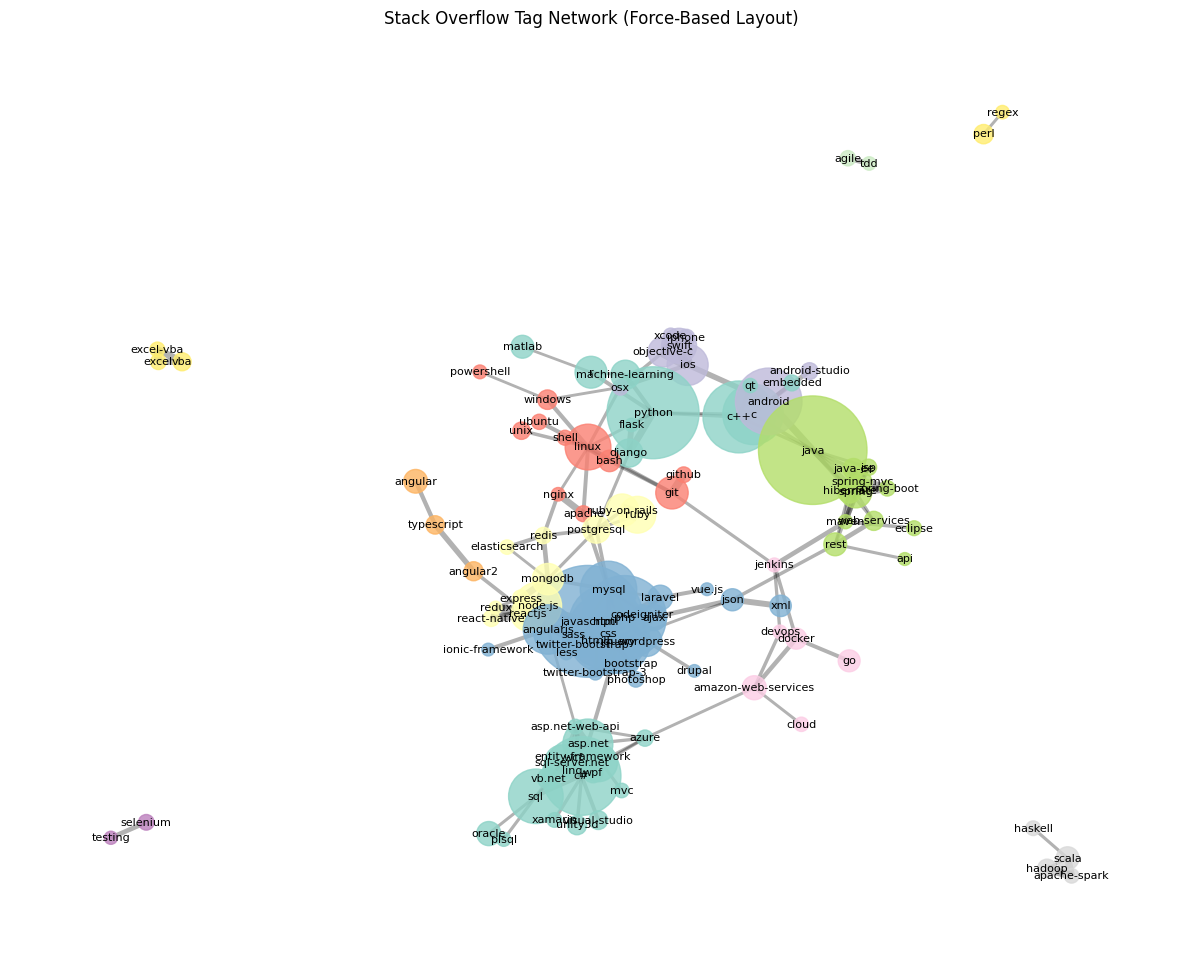

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import zipfile
import os

# -----------------------------
# 1– Load Dataset
# -----------------------------

# Unzip the uploaded archive
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# List files in /content/ to verify extraction
# print(os.listdir('/content/')) # Uncomment to debug file names

nodes = pd.read_csv("/content/stack_network_nodes.csv")
links = pd.read_csv("/content/stack_network_links.csv")

print("Nodes Shape:", nodes.shape)
print("Links Shape:", links.shape)

# -----------------------------
# 2– Create Graph
# -----------------------------
G = nx.Graph()

# Add nodes with attributes
for _, row in nodes.iterrows():
    G.add_node(
        row["name"],  # Changed from row["id"] to row["name"]
        label=row["name"],
        group=row["group"],
        size=row["nodesize"] # Changed from row["size"] to row["nodesize"]
    )

# Add edges with weight
for _, row in links.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["value"]
    )

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())

# -----------------------------
# 3– Force-Based Layout
# -----------------------------
plt.figure(figsize=(15, 12))

pos = nx.spring_layout(G, k=0.3)  # Force-directed layout

# Node sizes
node_sizes = [G.nodes[node]["size"] * 10 for node in G.nodes()]

# Edge widths
edge_widths = [G[u][v]["weight"] * 0.1 for u, v in G.edges()]

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=[G.nodes[n]["group"] for n in G.nodes()],
    cmap=plt.cm.Set3,
    alpha=0.8
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.3
)

# Draw labels (optional if graph small)
nx.draw_networkx_labels(
    G, pos,
    labels={n: G.nodes[n]["label"] for n in G.nodes()},
    font_size=8
)

plt.title("Stack Overflow Tag Network (Force-Based Layout)")
plt.axis("off")
plt.show()